In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Download and load the CIFAR-10 dataset, splitting it into Training and Testing sets
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
 
# Normalize pixel values from a 0-255 scale down to a 0-1 scale to help the model learn faster
X_train = X_train / 255.0
X_test  = X_test  / 255.0
 
# Flatten the target labels from a 2D array (e.g., [[3]]) into a 1D list (e.g., [3])
y_train = y_train.reshape(-1,)
y_test  = y_test.reshape(-1,)
 
# Define the human-readable names for the 10 image categories
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
 
# Print the dimensions of the datasets to verify they loaded correctly
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (50000, 32, 32, 3)
X_test shape : (10000, 32, 32, 3)


In [4]:
# Create an image generator that applies random transformations to prevent overfitting
datagen = ImageDataGenerator(
    horizontal_flip=True,       # Randomly flip images left-to-right
    width_shift_range=0.1,      # Randomly shift the image horizontally by 10%
    height_shift_range=0.1,     # Randomly shift the image vertically by 10%
    rotation_range=15,          # Randomly rotate the image by up to 15 degrees
    zoom_range=0.1              # Randomly zoom in or out by 10%
)

# Apply the augmentation generator to the training data
datagen.fit(X_train)

In [ ]:
# Install the TensorFlow library if it is not already installed on the system
!pip install tensorflow

# Core TensorFlow library and Keras modules for building the neural network
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

# Tool for Data Augmentation (modifying images on the fly during training)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Callbacks to monitor training and adjust learning rates dynamically
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Scikit-Learn tools for evaluating the model's accuracy and drawing the confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

# Libraries for numerical operations and data visualization (graphs/charts)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


In [5]:
# Initialize a sequential neural network (layers are stacked one after another)
new_cnn = models.Sequential([
 
    # --- Block 1: Extract Low-Level Features (Edges, Colors) ---
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(), # Stabilizes learning by normalizing data between layers
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)), # Compresses the image dimensions to save computation
    layers.Dropout(0.25),        # Randomly turns off 25% of neurons to prevent overfitting
 
    # --- Block 2: Extract Mid-Level Features (Textures, Basic Shapes) ---
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
 
    # --- Block 3: Extract High-Level Semantic Features (Object Parts) ---
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
 
    # --- Classification Head: Make the Final Prediction ---
    layers.Flatten(),                      # Convert the 2D feature maps into a 1D vector
    layers.Dense(256, activation='relu'),  # High-capacity reasoning layer
    layers.BatchNormalization(),
    layers.Dropout(0.5),                   # Heavy 50% dropout to strictly prevent memorization
    layers.Dense(10, activation='softmax') # Output layer: Gives probabilities for the 10 classes
])
 
# Display a table summarizing the model's architecture and total parameters
new_cnn.summary()

C:\Users\jingy\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256)                 │           1,0

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [6]:
# Configure the learning process before training begins
new_cnn.compile(
    optimizer='adam',                        # Smart optimizer that adapts learning rates automatically
    loss='sparse_categorical_crossentropy',  # Calculates prediction error for integer labels
    metrics=['accuracy']                     # Track overall accuracy during training
)

# Callback 1: Reduces learning rate if the model stops improving (val_loss plateaus for 5 epochs)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)
 
# Callback 2: Stops training entirely if no improvement is seen for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True, # Automatically reverts to the best performing epoch's weights
    verbose=1
)

In [7]:
# Train the model using the augmented images and validation data
history = new_cnn.fit(
    datagen.flow(X_train, y_train, batch_size=64), # Feed data in batches of 64 images
    epochs=30,                                     # Run for a maximum of 30 full passes
    validation_data=(X_test, y_test),              # Test against unseen data after each epoch
    callbacks=[reduce_lr, early_stop]              # Attach the monitoring tools
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 217ms/step - accuracy: 0.4128 - loss: 1.7203 - val_accuracy: 0.4699 - val_loss: 1.6293 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 200s 255ms/step - accuracy: 0.5566 - loss: 1.2394 - val_accuracy: 0.6194 - val_loss: 1.0913 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 260ms/step - accuracy: 0.6171 - loss: 1.0853 - val_accuracy: 0.6547 - val_loss: 0.9998 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 258ms/step - accuracy: 0.6570 - loss: 0.9746 - val_accuracy: 0.6755 - val_loss: 0.9660 - learning_rate: 0.0010
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 234ms/step - accuracy: 0.6765 - loss: 0.9182 - val_accuracy: 0.7187 - val_loss: 0.8128 - learning_rate: 0.0010
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 217s 253ms/step - accuracy: 0.7008 - loss: 0.8567 - val_accuracy: 0.6929 - val_loss: 0.9055 - learning_rate: 0.0010
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 208s 266ms/step - accura

In [14]:
# Calculate final accuracy and loss using the unseen testing dataset
test_loss, test_accuracy = new_cnn.evaluate(X_test, y_test, verbose=0)

# Print the final results in a cleanly formatted string
print(f"\nNew CNN  →  Test Accuracy: {test_accuracy*100:.2f}%  |  Test Loss: {test_loss:.4f}")


New CNN  →  Test Accuracy: 82.65%  |  Test Loss: 0.5192


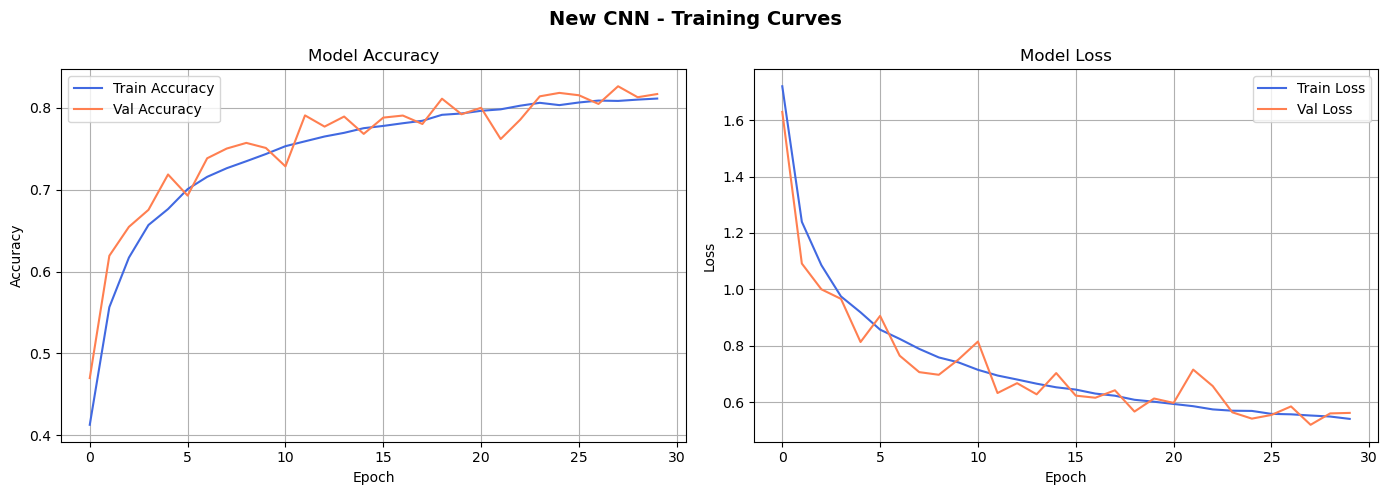

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',     color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
 
axes[1].plot(history.history['loss'],     label='Train Loss',     color='royalblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='coral')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)
 
plt.suptitle('New CNN - Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
y_pred_probs   = new_cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step


In [17]:
print("Classification Report - New CNN:\n")
print(classification_report(y_test, y_pred_classes, target_names=classes))

Classification Report - New CNN:

              precision    recall  f1-score   support

    airplane       0.89      0.85      0.87      1000
  automobile       0.92      0.95      0.94      1000
        bird       0.86      0.69      0.77      1000
         cat       0.79      0.59      0.67      1000
        deer       0.81      0.82      0.81      1000
         dog       0.84      0.72      0.78      1000
        frog       0.58      0.98      0.73      1000
       horse       0.93      0.84      0.88      1000
        ship       0.94      0.91      0.93      1000
       truck       0.89      0.91      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



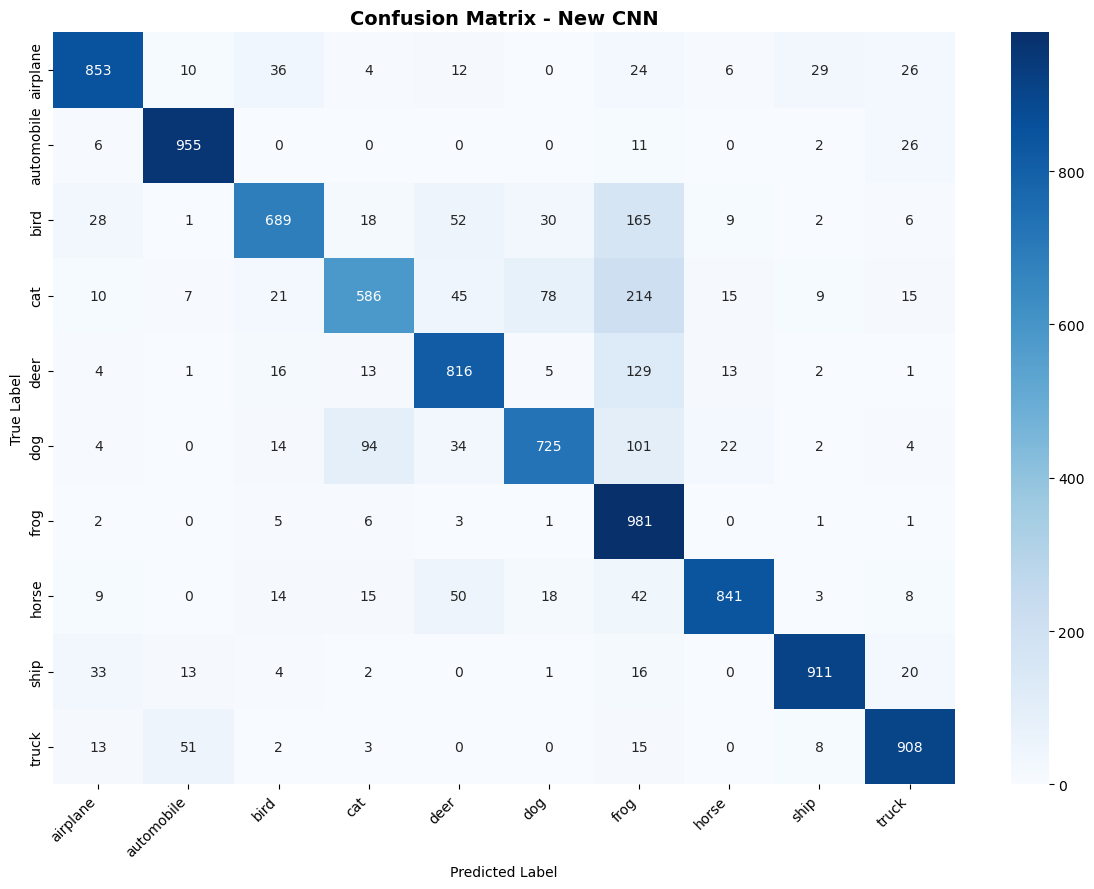

In [18]:
cm = confusion_matrix(y_test, y_pred_classes)
 
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - New CNN', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()